In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from dataclasses import dataclass
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import torch.nn.functional as F

sys.path.append('../') 
try:
    from NeuroHDC.FHRR import *
    from NeuroHDC.fn import *
    from conformalHDC.models import *
    from conformalHDC.methods import *
    from conformalHDC.utils import *
except ImportError:
    print("Warning: NeuroHDC or conformalHDC modules not found. Ensure '../' is in path.")

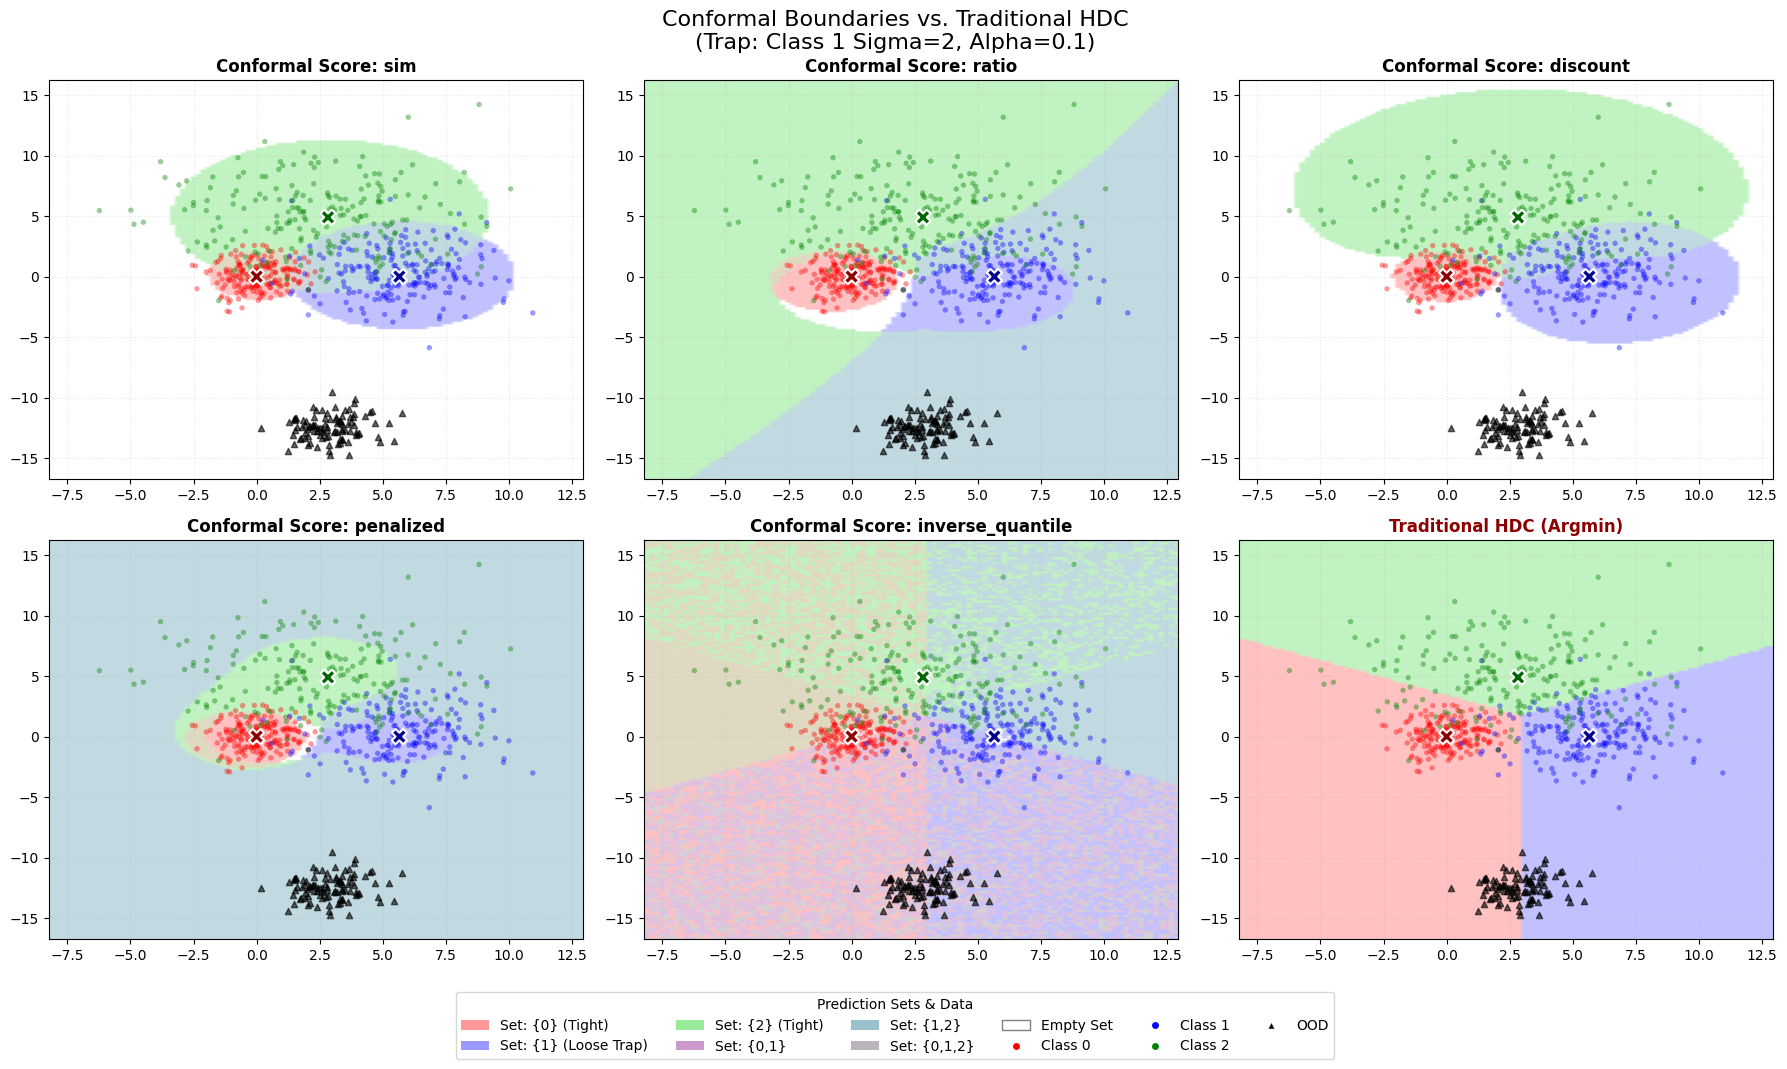

In [11]:
# ==========================================
# 1. GEOMETRY & DATA UTILS
# ==========================================
def setup_triangle_geometry(separation_factor, rng):
    dim = 2
    ref_sigma = 1.0
    r_ref = ref_sigma * np.sqrt(dim)
    dist = separation_factor * (r_ref + r_ref)

    mu0 = np.array([0.0, 0.0])
    mu1 = np.array([dist, 0.0])
    mu2 = np.array([dist / 2, (np.sqrt(3) / 2) * dist])
    
    return np.stack([mu0, mu1, mu2]).astype(np.float32)

def generate_samples_3class(n_samples, prototypes, sigmas, rng):
    X_list = []
    y_list = []
    dim = prototypes.shape[1]
    
    for label, (mu, sigma) in enumerate(zip(prototypes, sigmas)):
        X_c = rng.randn(n_samples, dim) * sigma + mu
        X_list.append(X_c)
        y_list.append(np.full(n_samples, label))
        
    X = np.concatenate(X_list).astype(np.float32)
    y = np.concatenate(y_list).astype(int)
    return X, y

def generate_ood_blob(n_samples, prototypes, rng):
    center = np.mean(prototypes, axis=0)
    direction = np.array([0.0, -1.0]) 
    dist = np.linalg.norm(prototypes[2] - prototypes[0]) * 2.5
    mu_ood = center + direction * dist
    X_ood = rng.randn(n_samples, 2) * 1.0 + mu_ood 
    return X_ood.astype(np.float32)

# ==========================================
# 2. COLOR UTILS
# ==========================================
BASE_COLORS = {
    0: np.array([1.0, 0.0, 0.0]), # Red
    1: np.array([0.0, 0.0, 1.0]), # Blue
    2: np.array([0.0, 0.8, 0.0])  # Green
}

def get_region_color(pset):
    if len(pset) == 0:
        return np.array([1.0, 1.0, 1.0]) # White
    
    color_sum = np.zeros(3)
    for lbl in pset:
        color_sum += BASE_COLORS[lbl]
    
    avg_color = color_sum / len(pset)
    # Pastel-ize
    final_color = avg_color * 0.4 + np.array([1.0, 1.0, 1.0]) * 0.6
    return final_color

# ==========================================
# 3. EXPERIMENT CONFIG
# ==========================================
SEED = 42
rng = np.random.RandomState(SEED)

SCORE_TYPES = ["sim", "ratio", "discount", "penalized", "inverse_quantile"]
# Ensure we have exactly 5 scores to leave the 6th spot for Vanilla
if len(SCORE_TYPES) > 5: SCORE_TYPES = SCORE_TYPES[:5]

SAMPLES_PER_CLASS = 200
SEPARATION_CONST = 2.0 
SIGMAS = [1.0, 2, 3] 
ALPHA = 0.1
MARGINAL = False 

prototypes = setup_triangle_geometry(SEPARATION_CONST, rng)
X_cal, y_cal = generate_samples_3class(SAMPLES_PER_CLASS, prototypes, SIGMAS, rng)
X_test, y_test = generate_samples_3class(SAMPLES_PER_CLASS, prototypes, SIGMAS, rng)
X_ood = generate_ood_blob(100, prototypes, rng)

# Define Grid
x_min, x_max = np.min([X_test[:,0].min(), X_ood[:,0].min()]) - 2, np.max([X_test[:,0].max(), X_ood[:,0].max()]) + 2
y_min, y_max = np.min([X_test[:,1].min(), X_ood[:,1].min()]) - 2, np.max([X_test[:,1].max(), X_ood[:,1].max()]) + 2
resolution = 0.2

xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                     np.arange(y_min, y_max, resolution))
grid_points = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

# ==========================================
# 4. PLOTTING LOOP
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11)) # Increased height for legend
axes = axes.flatten()

chdc = ConformalHDC(class_HVs=prototypes, class_labels=[0, 1, 2],
                    sim_measure="euclidean", random_state=SEED)

# Helper to plot common elements (data points)
def plot_data_layer(ax):
    colors_map = ['red', 'blue', 'green']
    colors_test = [colors_map[c] for c in y_test]
    ax.scatter(X_test[:, 0], X_test[:, 1], c=colors_test, s=15, alpha=0.4, edgecolors='none')
    ax.scatter(X_ood[:, 0], X_ood[:, 1], c='black', marker='^', s=20, alpha=0.6)
    ax.scatter(prototypes[:, 0], prototypes[:, 1], c=['darkred', 'darkblue', 'darkgreen'], 
               marker='X', s=120, edgecolor='white', linewidth=1.5, zorder=5)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle=':', alpha=0.3)

# --- A. Plot 5 Conformal Variants ---
for idx, stype in enumerate(SCORE_TYPES):
    ax = axes[idx]
    
    # Calibrate & Predict
    chdc.compute_calib_scores(X_cal, y_cal, score_type=stype)
    psets = chdc.set_valued_CP(grid_points, ALPHA, marginal=MARGINAL)
    
    # Color Regions
    region_img = np.zeros((xx.shape[0], xx.shape[1], 3))
    for i, pset in enumerate(psets):
        r, c = divmod(i, xx.shape[1])
        region_img[r, c] = get_region_color(pset)
        
    ax.imshow(region_img, extent=(x_min, x_max, y_min, y_max), origin='lower', alpha=0.6, aspect='auto')
    plot_data_layer(ax)
    ax.set_title(f"Conformal Score: {stype}", fontsize=12, fontweight='bold')

# --- B. Plot 6: Vanilla HDC (Traditional) ---
ax_vanilla = axes[5]

# Vanilla Prediction: Argmin of distances (Hard classification)
# Calculate distances to prototypes for grid
dists = []
for p in prototypes:
    d = np.linalg.norm(grid_points - p, axis=1)
    dists.append(d)
dists = np.stack(dists, axis=1)
preds_vanilla = np.argmin(dists, axis=1)

# Color Regions (No uncertainty, just single classes)
region_img_v = np.zeros((xx.shape[0], xx.shape[1], 3))
for i, pred in enumerate(preds_vanilla):
    r, c = divmod(i, xx.shape[1])
    # Convert prediction to singleton set format for color util
    region_img_v[r, c] = get_region_color({pred})

ax_vanilla.imshow(region_img_v, extent=(x_min, x_max, y_min, y_max), origin='lower', alpha=0.6, aspect='auto')
plot_data_layer(ax_vanilla)
ax_vanilla.set_title("Traditional HDC (Argmin)", fontsize=12, fontweight='bold', color='darkred')

# ==========================================
# 5. BOTTOM LEGEND
# ==========================================
legend_patches = [
    # Singletons
    Patch(facecolor=get_region_color({0}), label='Set: {0} (Tight)'),
    Patch(facecolor=get_region_color({1}), label='Set: {1} (Loose Trap)'),
    Patch(facecolor=get_region_color({2}), label='Set: {2} (Tight)'),
    # Uncertainty
    Patch(facecolor=get_region_color({0,1}), label='Set: {0,1}'),
    Patch(facecolor=get_region_color({1,2}), label='Set: {1,2}'),
    Patch(facecolor=get_region_color({0,1,2}), label='Set: {0,1,2}'),
    # Empty
    Patch(facecolor=[1,1,1], edgecolor='gray', label='Empty Set'),
    # Points
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Class 0'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Class 1'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', label='Class 2'),
    plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='black', label='OOD')
]

# Adjust layout to make room at bottom
plt.tight_layout(rect=[0, 0.1, 1, 0.95]) # Reserve bottom 10%

# Add legend to figure
fig.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, 0.02),
           ncol=6, fontsize=10, title="Prediction Sets & Data", frameon=True)

plt.suptitle(f"Conformal Boundaries vs. Traditional HDC\n(Trap: Class 1 Sigma={SIGMAS[1]}, Alpha={ALPHA})", fontsize=16)
plt.show()